# 📊 TỔNG QUAN DATASET MỚI — Synthetic Quote-Context (VND, TP.HCM)

Dữ liệu synthetic anh mentor gửi (thay cho việc phải tự sample). Notebook này **thống kê mô tả
toàn bộ trường** để nắm dữ liệu trước khi xây model mới.

| | |
|---|---|
| **Bối cảnh** | 3 khu ở TP.HCM (Crescent Mall · SC Vivo City · EcoGreen Sài Gòn) |
| **Thời gian** | 01/01 – 30/03/2026, tần suất **5 phút**, 89 ngày |
| **Tiền tệ** | **VND** · Đối thủ: "Synthetic Competitor" · 2 dịch vụ (Standard / Premium) |
| **Bảng chính** | `synthetic_intern_forecasting_v1` — **6,9M dòng × 70 cột** |
| **Điểm vàng** | Có **đủ 2 trường Boston thiếu**: `quote_duration` + chỉ số **cung–cầu** |

> ⭐ Data đã **chia sẵn split** (train/validation/calibration/test), tính sẵn **lag/history**,
> **baseline persistence**, và có **data dictionary** mô tả từng trường + cột `forecasting_availability`
> báo rõ trường nào được dùng làm feature, trường nào là leakage.

## Mục lục
1. Cấu hình & metadata dataset
2. Data dictionary — mô tả 70 trường
3. Nạp bảng forecasting (có tùy chọn sample)
4. Tổng quan: split, khu, dịch vụ, thời gian
5. Phân loại trường: feature dùng được vs leakage
6. Thống kê mô tả — biến SỐ
7. Thống kê mô tả — biến PHÂN LOẠI
8. ⭐ Trường mới so với Boston (duration + cung–cầu)
9. Phân bố target (giá VND, hệ số nhân)
10. Phân tích thiếu dữ liệu
11. Kết luận & so sánh Boston

---
# 1️⃣ Cấu hình & metadata dataset

In [1]:
import json, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.max_rows",300); pd.set_option("display.width",220); pd.set_option("display.max_colwidth",70)
BLUE,ORANGE,GREEN,RED="#0072B2","#E69F00","#009E73","#D55E00"

BASE = Path("../data/synthetic_data/synthetic_quote_context_sandbox_20260727_024458_utc")

cfg = json.load(open(BASE/"generation_config.json", encoding="utf-8"))
print("Phien ban artifact:", cfg["artifact_version"], "| profile:", cfg["artifact_profile"])
print("Thoi gian:", cfg["inclusive_start_date"], "->", cfg["inclusive_end_date"], f"({cfg['duration_days']:.0f} ngay, freq {cfg['frequency']})")
print("So khu:", cfg["n_zones"], "| So khach:", cfg["n_customers"], "| Tien te:", cfg["currency_code"])
print("Khu:", cfg["hex_display_names"])
print("Dich vu:", [s["service_name"] for s in cfg["services"]])
print("Do tre yeu cau (phut):", cfg["requested_lags_minutes"], "| cua so lich su:", cfg["history_window_minutes"],"phut")
print("\nArtifact summary:")
display(pd.read_csv(BASE/"artifact_summary.csv"))

Phien ban artifact: 2.1 | profile: intern
Thoi gian: 2026-01-01 -> 2026-03-30 (89 ngay, freq 5min)
So khu: 3 | So khach: 20000 | Tien te: VND
Khu: {'8765b574affffff': 'Crescent Mall', '8765b574bffffff': 'SC Vivo City', '8765b5759ffffff': 'EcoGreen Sài Gòn'}
Dich vu: ['Synthetic Standard Car', 'Synthetic Premium Car']
Do tre yeu cau (phut): [5, 10, 15, 30] | cua so lich su: 60 phut

Artifact summary:


,name,type,rows,columns,parts,bytes
0,synthetic_competitor_quote_feed_v1,dataframe,1724971.0,43.0,39,34095832
1,synthetic_data_dictionary_v1,dataframe,251.0,6.0,1,2709
2,synthetic_information_availability_v1,dataframe,9.0,4.0,1,774
3,synthetic_intern_forecasting_v1,dataframe,6897051.0,70.0,198,431098036
4,synthetic_scenario_catalog_v1,dataframe,1.0,3.0,1,139
5,synthetic_split_manifest_v1,dataframe,1724971.0,9.0,17,11731708
6,synthetic_stress_competitor_quote_feed_v1,dataframe,21469.0,43.0,3,427249
7,synthetic_stress_forecasting_v1,dataframe,67576.0,70.0,3,4249728
8,synthetic_stress_scenario_catalog_v1,dataframe,4.0,5.0,1,302
9,synthetic_zones_v1,dataframe,3.0,8.0,3,722


---
# 2️⃣ Data dictionary — mô tả 70 trường bảng forecasting

Cột **`forecasting_availability`** là quan trọng nhất — nó báo trường nào **được dùng làm feature**
và trường nào **KHÔNG được dùng** (leakage / chỉ để đánh giá).

In [2]:
dd = pd.read_csv(BASE/"shared/synthetic_data_dictionary_v1_part000.csv.gz")
dd_f = dd[dd.table=="synthetic_intern_forecasting_v1"].reset_index(drop=True)

print("Y nghia cac muc forecasting_availability:")
display(dd[["forecasting_availability","availability_rule"]].drop_duplicates().reset_index(drop=True))

print("\n70 truong bang forecasting (ten + mo ta + duoc dung khong):")
display(dd_f[["column","dtype","forecasting_availability","description"]])

Y nghia cac muc forecasting_availability:


,forecasting_availability,availability_rule
0,available_at_quote_request,"Route, service, time, and request context known when constructing ..."
1,identifier_or_evaluation_only,Do not use as a predictive signal unless specifically justified.
2,available_past_only,Constructed strictly from competitor observations at or before the...
3,available_if_observed_by_target,Allowed only when weather_observed_ts is not after the target time...
4,available_past_only,Constructed from earlier five-minute buckets and available at the ...
5,label_hidden_at_target,Target/evaluation label. Never include it in model inputs.



70 truong bang forecasting (ten + mo ta + duoc dung khong):


,column,dtype,forecasting_availability,description
0,forecast_example_id,object,identifier_or_evaluation_only,Synthetic field generated by the quote-context sandbox.
1,target_request_id,object,identifier_or_evaluation_only,Synthetic field generated by the quote-context sandbox.
2,target_timestamp,"datetime64[ns, UTC]",available_at_quote_request,Synthetic field generated by the quote-context sandbox.
3,current_timestamp_utc,"datetime64[ns, UTC]",available_at_quote_request,Five-minute synthetic market-bucket timestamp.
4,evaluation_month,object,identifier_or_evaluation_only,Independent monthly forecasting fold in YYYY-MM form.
5,competitor_platform,object,available_at_quote_request,Public-safe synthetic competitor/platform display label.
6,service_id,object,available_at_quote_request,Synthetic service identifier; not a production service ID.
7,service_name,object,available_at_quote_request,Synthetic field generated by the quote-context sandbox.
8,pickup_zone_id,object,available_at_quote_request,Synthetic pickup-zone identifier.
9,dropoff_zone_id,object,available_at_quote_request,Synthetic drop-off-zone identifier.


---
# 3️⃣ Nạp bảng forecasting

Bảng đầy đủ **6,9M dòng ~6,5 GB RAM**. Để nhẹ máy, mặc định lấy **mẫu 20%** (vẫn đại diện cho
thống kê). Đổi `SAMPLE_FRAC = 1.0` nếu muốn nạp toàn bộ.

In [3]:
SAMPLE_FRAC = 0.2   # 0.2 = mau 20% (~1.4M dong). Dat 1.0 de nap toan bo (~6.5GB RAM).

parts = sorted(glob.glob(str(BASE/"hexes/*/synthetic_intern_forecasting_v1_part*.csv.gz")))
print(f"Nap {len(parts)} part (frac={SAMPLE_FRAC})...")
def load(p):
    d = pd.read_csv(p)
    return d.sample(frac=SAMPLE_FRAC, random_state=42) if SAMPLE_FRAC < 1 else d
df = pd.concat([load(p) for p in parts], ignore_index=True)
print(f"Da nap: {df.shape[0]:,} dong x {df.shape[1]} cot | RAM ~{df.memory_usage(deep=True).sum()/1e9:.2f} GB")

Nap 198 part (frac=0.2)...
Da nap: 1,379,423 dong x 70 cot | RAM ~2.73 GB


---
# 4️⃣ Tổng quan: split, khu, dịch vụ, thời gian

Khoang thoi gian: 2026-01-01 00:06:08+00:00 -> 2026-03-30 23:59:55+00:00


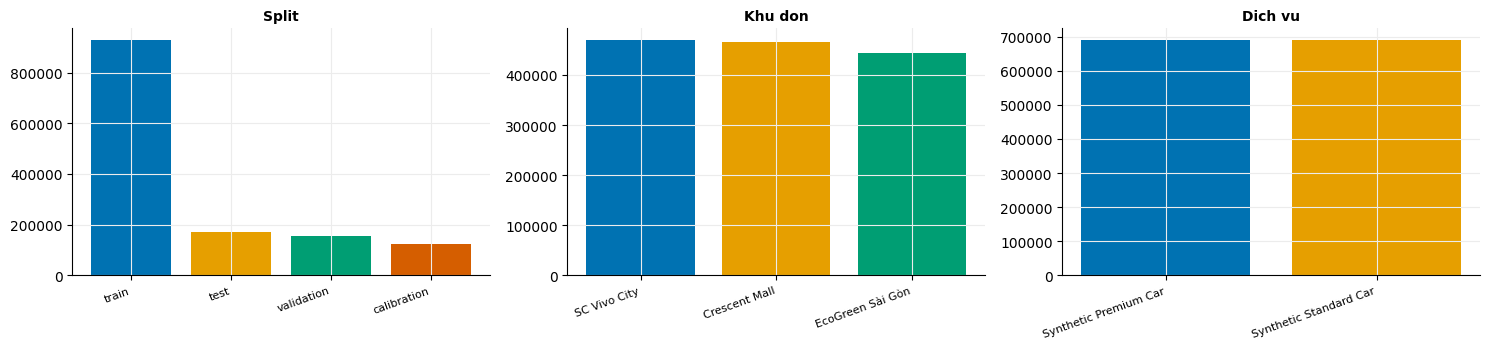

Split: {'train': 928334, 'test': 172878, 'validation': 154998, 'calibration': 123213}
Do tre yeu cau (phut): {5: 345260, 10: 344518, 15: 344888, 30: 344757}
Thang danh gia: {'2026-01': 480253, '2026-02': 433826, '2026-03': 465344}


In [4]:
df["target_timestamp"] = pd.to_datetime(df.target_timestamp)
print("Khoang thoi gian:", df.target_timestamp.min(), "->", df.target_timestamp.max())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a,(col,ten) in zip(ax, [("split","Split"),("pickup_location_name","Khu don"),("service_name","Dich vu")]):
    vc = df[col].value_counts()
    a.bar(range(len(vc)), vc.values, color=[BLUE,ORANGE,GREEN,RED][:len(vc)])
    a.set_xticks(range(len(vc))); a.set_xticklabels(vc.index, rotation=20, ha="right", fontsize=8)
    a.set_title(ten, fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

print("Split:", df.split.value_counts().to_dict())
print("Do tre yeu cau (phut):", df.requested_lag_minutes.value_counts().sort_index().to_dict())
print("Thang danh gia:", df.evaluation_month.value_counts().sort_index().to_dict())

---
# 5️⃣ Phân loại trường: feature dùng được vs leakage ⭐

Ghép data dictionary để biết trong 70 trường: bao nhiêu **dùng làm feature**, bao nhiêu **cấm dùng**.

In [5]:
avail = dd_f.groupby("forecasting_availability").column.apply(list)
print("So truong theo nhom:")
display(dd_f.forecasting_availability.value_counts().to_frame("so_truong"))
for nhom, cols in avail.items():
    print(f"\n[{nhom}] ({len(cols)} truong):")
    print("   " + ", ".join(cols))

So truong theo nhom:


,so_truong
forecasting_availability,
available_past_only,21
available_if_observed_by_target,20
available_at_quote_request,20
identifier_or_evaluation_only,6
label_hidden_at_target,3



[available_at_quote_request] (20 truong):
   target_timestamp, current_timestamp_utc, competitor_platform, service_id, service_name, pickup_zone_id, dropoff_zone_id, pickup_location_name, dropoff_location_name, pickup_hex_id_7, pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude, quote_distance, quote_duration, competitor_feed_id, target_hour, target_day_of_week, target_is_weekend

[available_if_observed_by_target] (20 truong):
   weather_observed_ts, weather_main, weather_description, weather_temp, weather_feels_like, weather_pressure, weather_humidity, weather_wind_speed, weather_wind_deg, weather_wind_deg_sin, weather_wind_deg_cos, weather_clouds_all, weather_age_minutes, weather_missing, weather_is_clear, weather_is_clouds, weather_is_rain, weather_is_mist, weather_is_thunderstorm, weather_is_drizzle

[available_past_only] (21 truong):
   pricing_quote_count_5m_lag, pricing_avg_shown_multiplier_5m_lag, pricing_demand_index_5m_lag, pricing_supply_index_5m_lag, pr

---
# 6️⃣ Thống kê mô tả — biến SỐ

`count, mean, std, min, 25%, 50%, 75%, max` cho mọi cột số, kèm **% thiếu**.

In [6]:
num = df.select_dtypes(include=[np.number])
desc = num.describe().T
desc["missing_%"] = (df[num.columns].isna().mean()*100).round(2).values
desc = desc[["count","mean","std","min","25%","50%","75%","max","missing_%"]]
print(f"So bien SO: {num.shape[1]}")
display(desc.round(3))

So bien SO: 48


,count,mean,std,min,25%,50%,75%,max,missing_%
pickup_latitude,1379423.0,10.731,0.010,10.722,10.722,10.727,10.745,10.745,0.0
pickup_longitude,1379423.0,106.722,0.012,106.706,106.706,106.728,106.732,106.732,0.0
dropoff_latitude,1379423.0,10.731,0.010,10.722,10.722,10.727,10.745,10.745,0.0
dropoff_longitude,1379423.0,106.723,0.011,106.706,106.706,106.728,106.732,106.732,0.0
quote_distance,1379423.0,6.553,2.183,1.102,5.372,6.168,8.030,45.000,0.0
quote_duration,1379423.0,1475.315,662.925,240.000,1014.740,1367.640,1813.570,10800.000,0.0
pricing_quote_count_5m_lag,1379423.0,138.108,21.008,6.000,132.000,142.000,151.000,205.000,0.0
pricing_avg_shown_multiplier_5m_lag,1379423.0,1.164,0.168,0.850,1.060,1.176,1.276,1.769,0.0
pricing_demand_index_5m_lag,1379423.0,115.444,43.513,15.000,88.218,117.665,145.752,298.580,0.0
pricing_supply_index_5m_lag,1379423.0,80.140,22.831,33.639,62.647,74.287,95.301,193.729,0.0


---
# 7️⃣ Thống kê mô tả — biến PHÂN LOẠI

Số giá trị khác nhau, giá trị phổ biến nhất, % thiếu cho mọi cột chữ / bool.

In [7]:
cat = df.select_dtypes(include=["object","bool"])
rows = []
for c in cat.columns:
    vc = df[c].value_counts()
    top = f"{vc.index[0]} ({vc.iloc[0]/len(df)*100:.1f}%)" if len(vc) else "-"
    rows.append({"cot":c, "so_gia_tri":df[c].nunique(), "pho_bien_nhat":top,
                 "missing_%":round(df[c].isna().mean()*100,2)})
print(f"So bien PHAN LOAI: {cat.shape[1]}")
display(pd.DataFrame(rows))

So bien PHAN LOAI: 21


,cot,so_gia_tri,pho_bien_nhat,missing_%
0,forecast_example_id,1379423,SYNQ-000042-0000861497-L10 (0.0%),0.0
1,target_request_id,1014317,SYNQ-000042-0000090846 (0.0%),0.0
2,current_timestamp_utc,25629,2026-01-30 09:40:00+00:00 (0.0%),0.0
3,evaluation_month,3,2026-01 (34.8%),0.0
4,competitor_platform,1,Synthetic Competitor (100.0%),0.0
5,service_id,2,SYN_PREMIUM (50.0%),0.0
6,service_name,2,Synthetic Premium Car (50.0%),0.0
7,pickup_zone_id,3,SYN_ZONE_001 (34.0%),0.0
8,dropoff_zone_id,3,SYN_ZONE_000 (36.5%),0.0
9,pickup_location_name,3,SC Vivo City (34.0%),0.0


---
# 8️⃣ ⭐ Trường MỚI so với Boston — duration + cung–cầu

Đây là 2 nhóm biến trung gian mà bộ Boston **thiếu** (gây sàn nhiễu + surge không đoán được).
Giờ đã có đầy đủ → kỳ vọng model cải thiện mạnh.

,count,mean,std,min,25%,50%,75%,max
quote_duration,1379423.0,1475.315,662.925,240.000,1014.740,1367.640,1813.570,10800.000
pricing_demand_index_5m_lag,1379423.0,115.444,43.513,15.000,88.218,117.665,145.752,298.580
pricing_supply_index_5m_lag,1379423.0,80.140,22.831,33.639,62.647,74.287,95.301,193.729
pricing_market_imbalance_5m_lag,1379423.0,1.521,0.667,0.151,1.074,1.460,1.912,5.730
pricing_quote_count_5m_lag,1379423.0,138.108,21.008,6.000,132.000,142.000,151.000,205.000
pricing_avg_shown_multiplier_5m_lag,1379423.0,1.164,0.168,0.850,1.060,1.176,1.276,1.769
latest_observed_quote_duration,1379423.0,1474.476,662.976,240.000,1014.640,1366.450,1812.230,10800.000
weather_temp,1379423.0,27.147,2.633,21.650,25.040,26.580,29.330,34.270
weather_humidity,1379423.0,77.733,11.011,45.440,69.780,79.330,86.350,100.000
weather_wind_speed,1379423.0,2.934,1.179,0.780,2.070,2.710,3.550,9.190


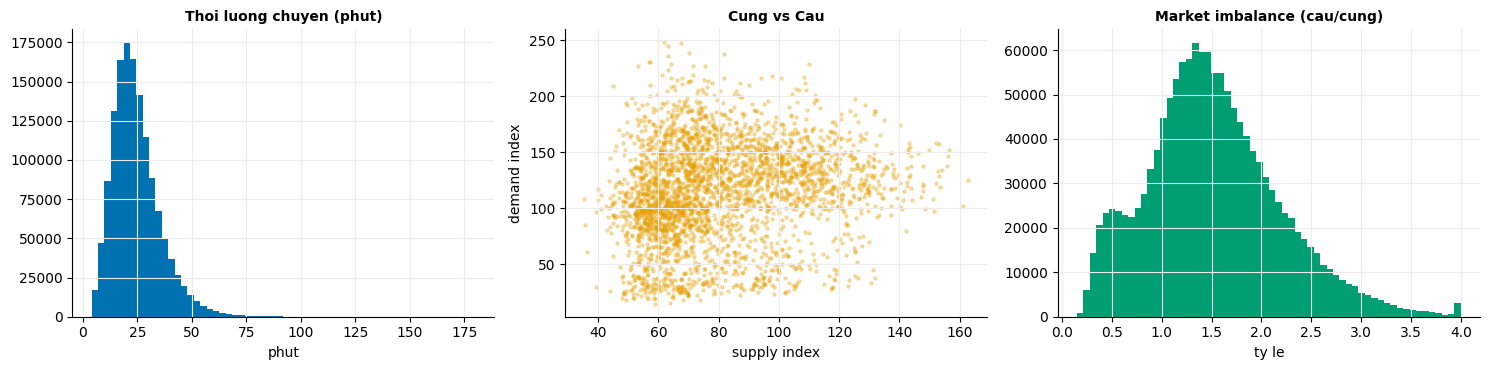

In [8]:
moi = ["quote_duration","pricing_demand_index_5m_lag","pricing_supply_index_5m_lag",
       "pricing_market_imbalance_5m_lag","pricing_quote_count_5m_lag","pricing_avg_shown_multiplier_5m_lag",
       "latest_observed_quote_duration","weather_temp","weather_humidity","weather_wind_speed"]
moi = [c for c in moi if c in df.columns]
display(df[moi].describe().T.round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(df.quote_duration/60, bins=60, color=BLUE); ax[0].set_title("Thoi luong chuyen (phut)", fontweight="bold", fontsize=10)
ax[0].set_xlabel("phut")
ax[1].scatter(df.pricing_supply_index_5m_lag.sample(3000, random_state=1),
              df.pricing_demand_index_5m_lag.sample(3000, random_state=1), s=5, alpha=.3, color=ORANGE)
ax[1].set_xlabel("supply index"); ax[1].set_ylabel("demand index"); ax[1].set_title("Cung vs Cau", fontweight="bold", fontsize=10)
ax[2].hist(df.pricing_market_imbalance_5m_lag.clip(0,4), bins=60, color=GREEN)
ax[2].set_title("Market imbalance (cau/cung)", fontweight="bold", fontsize=10); ax[2].set_xlabel("ty le")
plt.tight_layout(); plt.show()

---
# 9️⃣ Phân bố target (giá VND & hệ số nhân)

Hai biến mục tiêu của bài toán: `target_shown_price` (giá) và `target_shown_multiplier` (hệ số nhân).

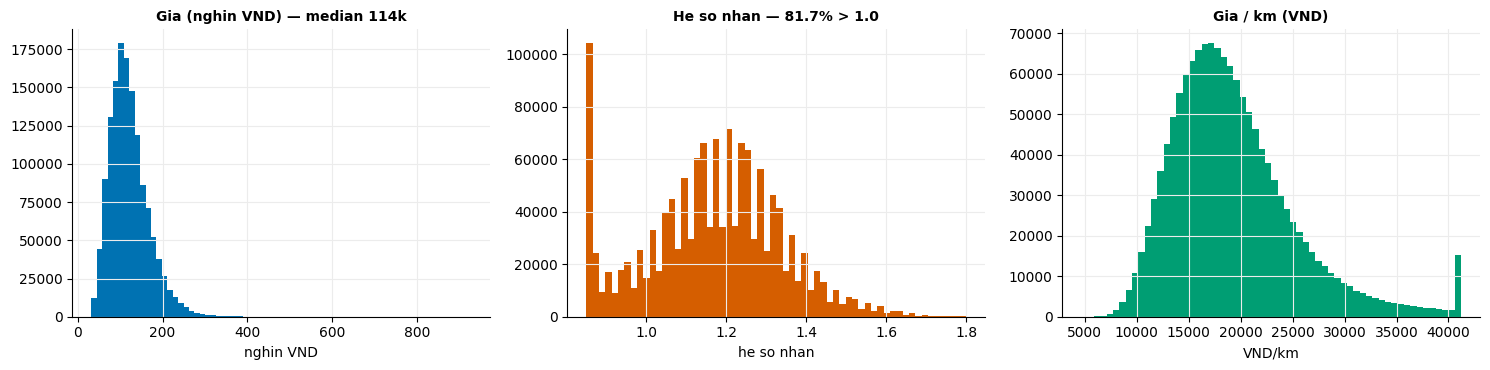

=== SO SANH SURGE voi Boston ===
  Data VN moi : 81.7% chuyen co surge
  Boston cu   : ~13.5% chuyen co surge
  -> Surge PHO BIEN hon nhieu -> model he so nhan se co nhieu tin hieu hon.


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(df.target_shown_price/1000, bins=70, color=BLUE)
ax[0].set_title(f"Gia (nghin VND) — median {df.target_shown_price.median()/1000:.0f}k", fontweight="bold", fontsize=10)
ax[0].set_xlabel("nghin VND")
ax[1].hist(df.target_shown_multiplier, bins=60, color=RED)
ax[1].set_title(f"He so nhan — {(df.target_shown_multiplier>1).mean()*100:.1f}% > 1.0", fontweight="bold", fontsize=10)
ax[1].set_xlabel("he so nhan")
ax[2].hist(df.target_price_per_km.clip(0, df.target_price_per_km.quantile(.99)), bins=60, color=GREEN)
ax[2].set_title("Gia / km (VND)", fontweight="bold", fontsize=10); ax[2].set_xlabel("VND/km")
plt.tight_layout(); plt.show()

print("=== SO SANH SURGE voi Boston ===")
print(f"  Data VN moi : {(df.target_shown_multiplier>1).mean()*100:.1f}% chuyen co surge")
print(f"  Boston cu   : ~13.5% chuyen co surge")
print("  -> Surge PHO BIEN hon nhieu -> model he so nhan se co nhieu tin hieu hon.")

---
# 🔟 Phân tích thiếu dữ liệu

In [10]:
miss = (df.isna().mean()*100).sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    print(f"{len(miss)} cot co thieu du lieu:")
    display(miss.round(2).to_frame("missing_%"))
    fig, ax = plt.subplots(figsize=(9, max(2,len(miss)*0.3)))
    ax.barh(range(len(miss)), miss.values, color=RED)
    ax.set_yticks(range(len(miss))); ax.set_yticklabels(miss.index, fontsize=8)
    ax.set_xlabel("% thieu"); ax.invert_yaxis(); plt.tight_layout(); plt.show()
else:
    print("Khong cot nao thieu du lieu (0% missing toan bo).")

# weather co the thieu do fail rate
if "weather_missing" in df.columns:
    print(f"\nweather_missing = True: {df.weather_missing.mean()*100:.2f}% (thoi tiet khong quan sat duoc)")

Khong cot nao thieu du lieu (0% missing toan bo).

weather_missing = True: 1.71% (thoi tiet khong quan sat duoc)


---
# 1️⃣1️⃣ Kết luận & so sánh với Boston

| Khía cạnh | Boston (cũ) | Synthetic VN (mới) |
|---|---|---|
| Tiền tệ / vùng | USD, Boston | **VND, 3 khu TP.HCM** |
| Thời lượng chuyến (`duration`) | ❌ thiếu → sàn nhiễu ~2 USD | ✅ **có** (`quote_duration`) |
| Tín hiệu cung–cầu | ❌ thiếu → surge không đoán được | ✅ **có** (demand/supply/imbalance index) |
| Tỷ lệ surge | 13,5% (hiếm) | **81,7%** (phổ biến) |
| Split | tự chia | ✅ **chia sẵn** (train/val/calib/test) |
| Lag / history | tự tính | ✅ **tính sẵn** (5/10/15/30p + history 60m) |
| Baseline persistence | tự tính | ✅ **có sẵn** (`persistence_prediction`) |
| Độ trễ quan sát | suy ra | ✅ **tường minh** (`actual_observation_age_minutes`, `requested_lag_minutes`) |

**Ý nghĩa cho dự án:**
- Hai nhược điểm lớn nhất của Boston (thiếu duration + cung–cầu) **đã được giải quyết** → model
  giá kỳ vọng vượt trần sàn nhiễu cũ, model hệ số nhân có tín hiệu thật để học.
- Data đã chuẩn hoá sẵn (split, lag, baseline) → **đỡ công tiền xử lý**, tập trung vào model.
- Có `forecasting_availability` → biết chính xác trường nào được dùng, tránh leakage.

**Bước tiếp theo:** xây pipeline train trên bộ mới (giữ nguyên kiến trúc cũ: model giá + surge
2 tầng + conformal), so sánh hiệu suất với bộ Boston để chứng minh giá trị của 2 trường mới.